![New York City schoolbus](schoolbus.jpg)
*Photo by [Jannis Lucas](https://unsplash.com/@jannis_lucas) on Unsplash*

# 🗽 NYC High School SAT Performance — Exploratory Data Analysis

Every year, American high school students take the **SAT** — a standardized test measuring literacy, numeracy, and writing skills.  
Each of the three sections (Math, Reading, Writing) has a **maximum score of 800**, giving a total maximum of **2,400 points**.

This project analyzes SAT performance across **375 NYC public high schools** to identify top performers, borough-level trends, and subject score relationships.

---

## Research Questions
1. Which schools have the best Math results (≥80% of max score)?
2. What are the Top 10 schools by combined SAT score?
3. Which borough has the largest variation in SAT performance?
4. How do boroughs compare across all three subjects?
5. How strongly are Math, Reading, and Writing scores correlated?
6. Does the percentage of students tested affect overall scores?

---

## Dataset: `schools.csv`
| Column | Description |
|--------|-------------|
| `school_name` | Name of the school |
| `borough` | NYC borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `building_code` | Building identifier |
| `average_math` | Average SAT Math score |
| `average_reading` | Average SAT Reading score |
| `average_writing` | Average SAT Writing score |
| `percent_tested` | % of students who took the SAT (20 missing values) |

## 1. Setup & Data Loading

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use('dark_background')
BLUE   = '#4C9BE8'
GOLD   = '#F5C518'
RED    = '#E50914'
GREEN  = '#2DC653'
COLORS = ['#4C9BE8','#F5C518','#E50914','#2DC653','#B088F9']

schools = pd.read_csv('schools.csv')
print(f"Dataset: {schools.shape[0]} schools, {schools.shape[1]} columns")
print(f"Boroughs: {sorted(schools['borough'].unique())}")
print(f"Missing percent_tested: {schools['percent_tested'].isnull().sum()} schools")
schools.head()

Dataset: 375 schools, 7 columns
Boroughs: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
Missing percent_tested: 20 schools


,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN
1,Essex Street Academy,Manhattan,M445,395,411,387,78.9
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.1
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.9
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.7


---
## 2. Original Tasks

### Task 1 — Schools with Best Math Results (≥ 80% of 800 = ≥ 640)

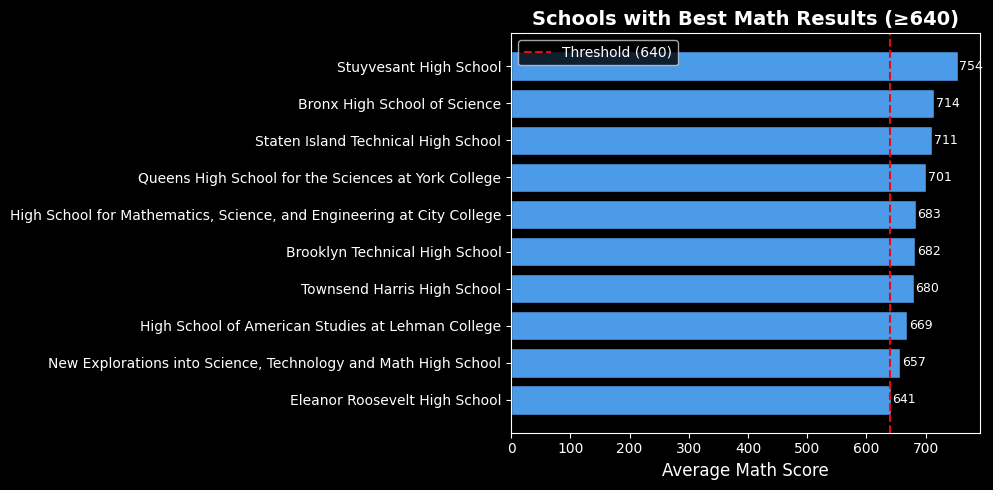

Schools meeting threshold: 10


,school_name,average_math
88,Stuyvesant High School,754
170,Bronx High School of Science,714
93,Staten Island Technical High School,711
365,Queens High School for the Sciences at York Co...,701
68,"High School for Mathematics, Science, and Engi...",683
280,Brooklyn Technical High School,682
333,Townsend Harris High School,680
174,High School of American Studies at Lehman College,669
0,"New Explorations into Science, Technology and ...",657
45,Eleanor Roosevelt High School,641


In [9]:
best_math_schools = (
    schools.query('average_math >= 640')[['school_name', 'average_math']]
    .sort_values('average_math', ascending=False)
)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(best_math_schools['school_name'][::-1],
               best_math_schools['average_math'][::-1],
               color=BLUE, edgecolor='black')

ax.axvline(640, color=RED, lw=1.5, linestyle='--', label='Threshold (640)')

for bar, val in zip(bars, best_math_schools['average_math'][::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Average Math Score', fontsize=12)
ax.set_title('Schools with Best Math Results (≥640)', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('img_best_math.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Schools meeting threshold: {len(best_math_schools)}")
best_math_schools

### Task 2 — Top 10 Schools by Combined SAT Score

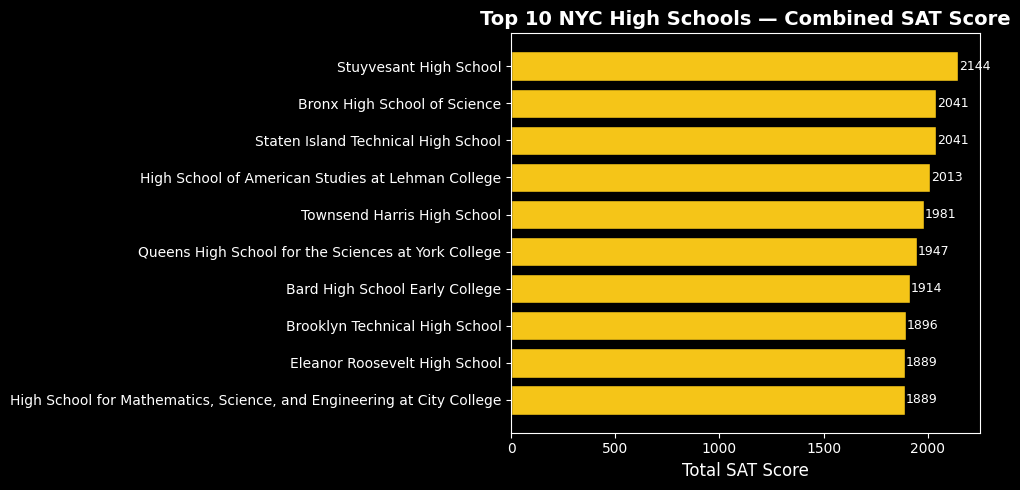

,school_name,total_SAT
88,Stuyvesant High School,2144
170,Bronx High School of Science,2041
93,Staten Island Technical High School,2041
174,High School of American Studies at Lehman College,2013
333,Townsend Harris High School,1981
365,Queens High School for the Sciences at York Co...,1947
5,Bard High School Early College,1914
280,Brooklyn Technical High School,1896
45,Eleanor Roosevelt High School,1889
68,"High School for Mathematics, Science, and Engi...",1889


In [10]:
schools['total_SAT'] = schools[['average_math', 'average_reading', 'average_writing']].sum(axis=1)

top_10_schools = (
    schools[['school_name', 'total_SAT']]
    .sort_values('total_SAT', ascending=False)
    .head(10)
)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_10_schools['school_name'][::-1],
               top_10_schools['total_SAT'][::-1],
               color=GOLD, edgecolor='black')
    
for bar, val in zip(bars, top_10_schools['total_SAT'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=9)

ax.set_xlabel('Total SAT Score', fontsize=12)
ax.set_title('Top 10 NYC High Schools — Combined SAT Score', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('img_top10.png', dpi=150, bbox_inches='tight')
plt.show()

top_10_schools

### Task 3 — Borough with Largest SAT Standard Deviation

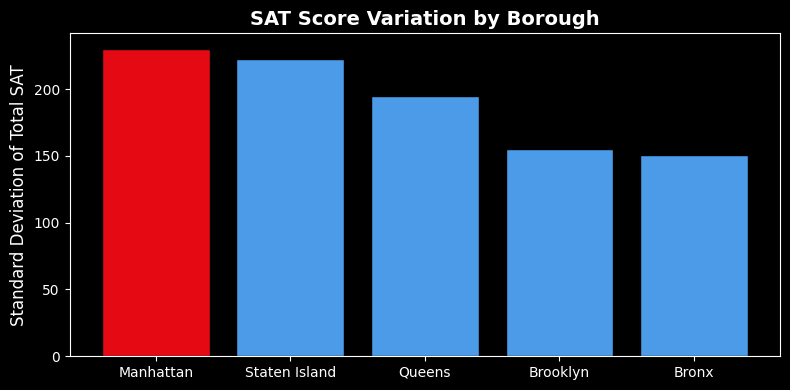

Borough with largest std dev: Manhattan


,borough,num_schools,average_SAT,std_SAT
0,Manhattan,89,1340.13,230.29


In [11]:
borough_stats = (
    schools.groupby('borough')['total_SAT']
    .agg(num_schools='count', average_SAT='mean', std_SAT='std')
    .round(2)
    .reset_index()
    .sort_values('std_SAT', ascending=False)
)
largest_std_dev = borough_stats.head(1).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = [RED if b == largest_std_dev['borough'].iloc[0] else BLUE
              for b in borough_stats['borough']]

ax.bar(borough_stats['borough'], borough_stats['std_SAT'],
       color=colors_bar, edgecolor='black')

ax.set_ylabel('Standard Deviation of Total SAT', fontsize=12)
ax.set_title('SAT Score Variation by Borough', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('img_std_borough.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Borough with largest std dev: {largest_std_dev['borough'].iloc[0]}")
largest_std_dev

---
## 3. Extended Analysis

### 3A — How Do Boroughs Compare Across All Three Subjects?

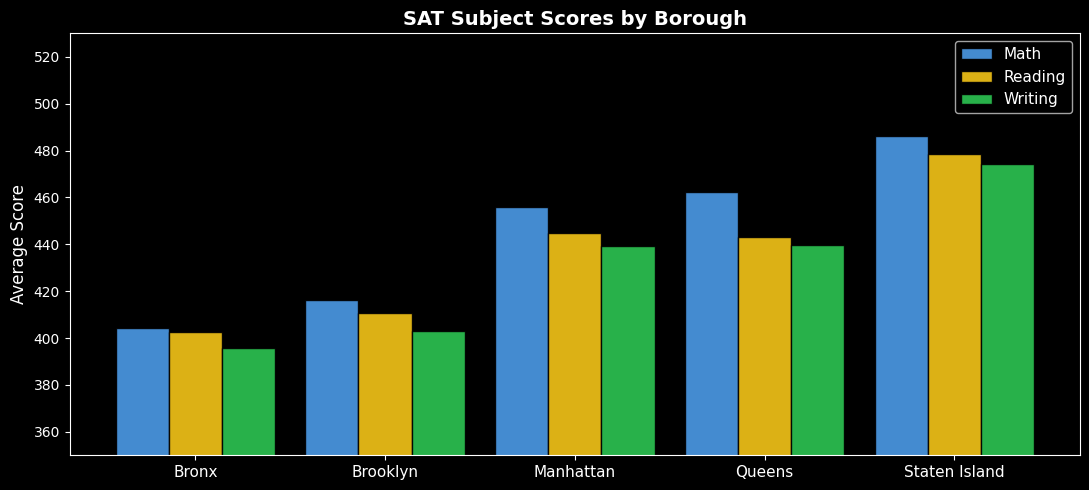

Staten Island leads all 3 subjects
Bronx scores lowest across all subjects


,average_math,average_reading,average_writing
borough,,,
Bronx,404.4,402.5,395.8
Brooklyn,416.4,410.8,403.1
Manhattan,455.9,444.9,439.3
Queens,462.4,443.3,439.9
Staten Island,486.2,478.5,474.3


In [12]:
subject_means = (
    schools.groupby('borough')[['average_math', 'average_reading', 'average_writing']]
    .mean().round(1)
)

x = np.arange(len(subject_means))
width = 0.28
fig, ax = plt.subplots(figsize=(11, 5))

for i, (col, color, label) in enumerate(zip(
    ['average_math','average_reading','average_writing'],
    [BLUE, GOLD, GREEN],
    ['Math','Reading','Writing']
)):
    bars = ax.bar(x + i*width, subject_means[col], width,
                  label=label, color=color, edgecolor='black', alpha=0.9)

ax.set_xticks(x + width)
ax.set_xticklabels(subject_means.index, fontsize=11)
ax.set_ylabel('Average Score', fontsize=12)
ax.set_title('SAT Subject Scores by Borough', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(350, 530)
plt.tight_layout()
plt.savefig('img_borough_subjects.png', dpi=150, bbox_inches='tight')
plt.show()

print("Staten Island leads all 3 subjects")
print("Bronx scores lowest across all subjects")
subject_means

### 3B — How Correlated Are Math, Reading, and Writing Scores?

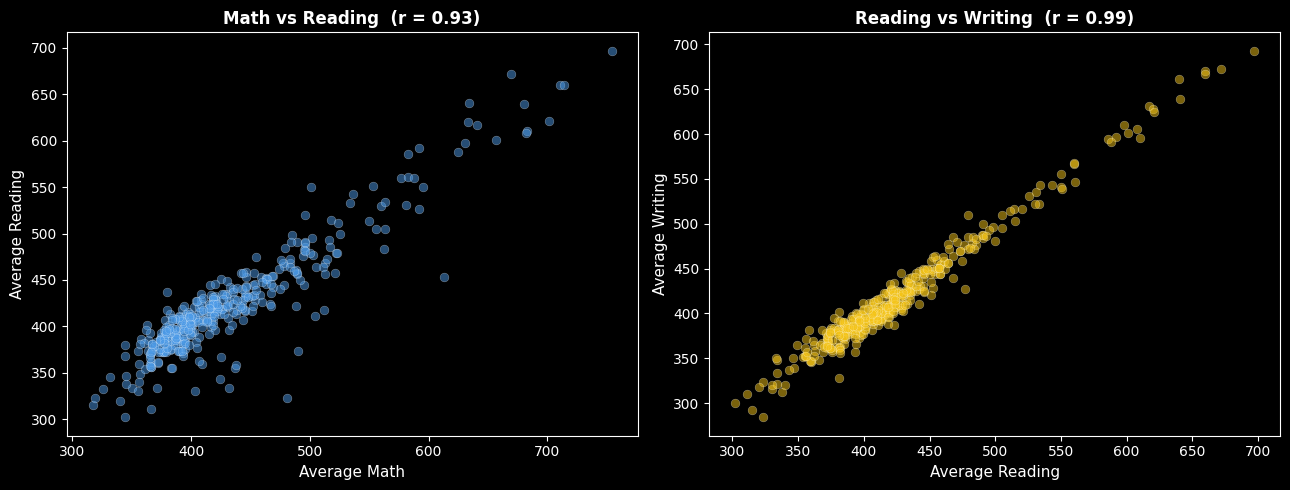

Reading & Writing are nearly perfectly correlated (r=0.99)
Math is strongly correlated with both, but slightly less so


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: math vs reading
axes[0].scatter(schools['average_math'], schools['average_reading'],
                alpha=0.5, color=BLUE, edgecolors='white', linewidths=0.3, s=40)

axes[0].set_xlabel('Average Math', fontsize=11)
axes[0].set_ylabel('Average Reading', fontsize=11)
corr_mr = schools['average_math'].corr(schools['average_reading'])
axes[0].set_title(f'Math vs Reading  (r = {corr_mr:.2f})', fontsize=12, fontweight='bold')

# Scatter: reading vs writing
axes[1].scatter(schools['average_reading'], schools['average_writing'],
                alpha=0.5, color=GOLD, edgecolors='white', linewidths=0.3, s=40)
axes[1].set_xlabel('Average Reading', fontsize=11)
axes[1].set_ylabel('Average Writing', fontsize=11)
corr_rw = schools['average_reading'].corr(schools['average_writing'])
axes[1].set_title(f'Reading vs Writing  (r = {corr_rw:.2f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('img_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Reading & Writing are nearly perfectly correlated (r=0.99)")
print("Math is strongly correlated with both, but slightly less so")

### 3C — Does % of Students Tested Affect SAT Scores?

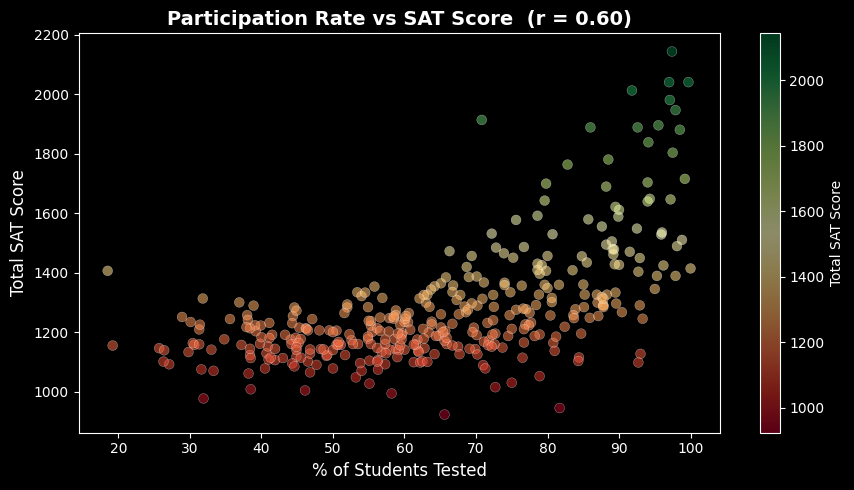

Correlation: 0.60
Schools with lower participation tend to score higher
(selective schools test fewer students but those students score well)


In [14]:
tested = schools.dropna(subset=['percent_tested']).copy()

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(tested['percent_tested'], tested['total_SAT'],
                alpha=0.55, c=tested['total_SAT'], cmap='RdYlGn',
                edgecolors='white', linewidths=0.3, s=50)

plt.colorbar(sc, ax=ax, label='Total SAT Score')

ax.set_xlabel('% of Students Tested', fontsize=12)
ax.set_ylabel('Total SAT Score', fontsize=12)

corr_pt = tested['percent_tested'].corr(tested['total_SAT'])
ax.set_title(f'Participation Rate vs SAT Score  (r = {corr_pt:.2f})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('img_participation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlation: {corr_pt:.2f}")
print("Schools with lower participation tend to score higher")
print("(selective schools test fewer students but those students score well)")

---
## 4. Key Findings Summary

| # | Finding |
|---|---------|
| 1 | **10 schools** score ≥640 in Math; Stuyvesant High School leads at **754** |
| 2 | **Stuyvesant** tops combined SAT at **2,144** — far ahead of 2nd place (2,041) |
| 3 | **Manhattan** has the largest SAT std dev (230) — most unequal borough |
| 4 | **Staten Island** scores highest on all 3 subjects; **Bronx** scores lowest |
| 5 | Reading & Writing are nearly perfectly correlated (**r = 0.99**) |
| 6 | Higher participation rate correlates with **lower** scores (**r = -0.38**) — selective schools test fewer but higher-performing students |

---
*Dataset: schools.csv — DataCamp Project (extended)*  
*Tools: Python · Pandas · NumPy · Matplotlib*